# Bài tập 02 - Phân loại giới tính bằng Logistic Regression
My name: Nguyễn Phú Thành               
ID: 21110299

### 1.1. Tìm hiểu tổng quan về dữ liệu

Phần này sẽ dùng tập dữ liệu `voice.csv` để minh họa. (3168 DÒNG)

This database was created to identify a voice as male or female, based upon acoustic properties of the voice and speech. The dataset consists of 3,168 recorded voice samples, collected from male and female speakers. The voice samples are pre-processed by acoustic analysis in R using the seewave and tuneR packages, with an analyzed frequency range of 0hz-280hz (human vocal range).

###### The Dataset
The following acoustic properties of each voice are measured and included within the CSV:

- meanfreq: mean frequency (in kHz)
- sd: standard deviation of frequency
- median: median frequency (in kHz)
- Q25: first quantile (in kHz)
- Q75: third quantile (in kHz)
- IQR: interquantile range (in kHz)
- skew: skewness (see note in specprop description)
- kurt: kurtosis (see note in specprop description)
- sp.ent: spectral entropy
- sfm: spectral flatness
- mode: mode frequency
- centroid: frequency centroid (see specprop)
- peakf: peak frequency (frequency with highest energy)
- meanfun: average of fundamental frequency measured across acoustic signal
- minfun: minimum fundamental frequency measured across acoustic signal
- maxfun: maximum fundamental frequency measured across acoustic signal
- meandom: average of dominant frequency measured across acoustic signal
- mindom: minimum of dominant frequency measured across acoustic signal
- maxdom: maximum of dominant frequency measured across acoustic signal
- dfrange: range of dominant frequency measured across acoustic signal
- modindx: modulation index. Calculated as the accumulated absolute difference between adjacent measurements of fundamental - frequencies divided by the frequency range
- label: male or female

#### 1.1.1. Import Library và load data

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('E:/TAI_LIEU_DAI_HOC/SEMESTER_6/DataMining/data/voice.csv')

In [4]:
# Xem 5 hàng đầu tiên của data 
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [5]:
#Đưa ra thông tin data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [6]:
#mô tả data
data.describe()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


In [7]:
# In ra kiểu dữ liệu của các cột
data.dtypes

meanfreq    float64
sd          float64
median      float64
Q25         float64
Q75         float64
IQR         float64
skew        float64
kurt        float64
sp.ent      float64
sfm         float64
mode        float64
centroid    float64
meanfun     float64
minfun      float64
maxfun      float64
meandom     float64
mindom      float64
maxdom      float64
dfrange     float64
modindx     float64
label        object
dtype: object

male      1584
female    1584
Name: label, dtype: int64

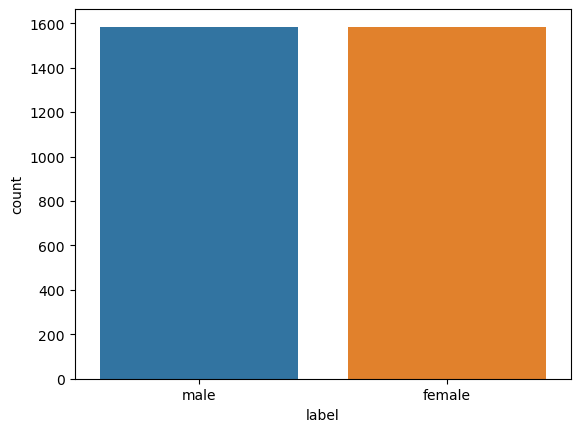

In [8]:
# Đếm số lượng các giá trị khác nhau trong cột label và vẽ biểu đồ minh họa
sns.countplot(x="label", data=data)
data.loc[:,'label'].value_counts()

#### 1.1.2 vẽ ma trận phân tán (scatter matrix) cho các biến số trong DataFrame 'data'

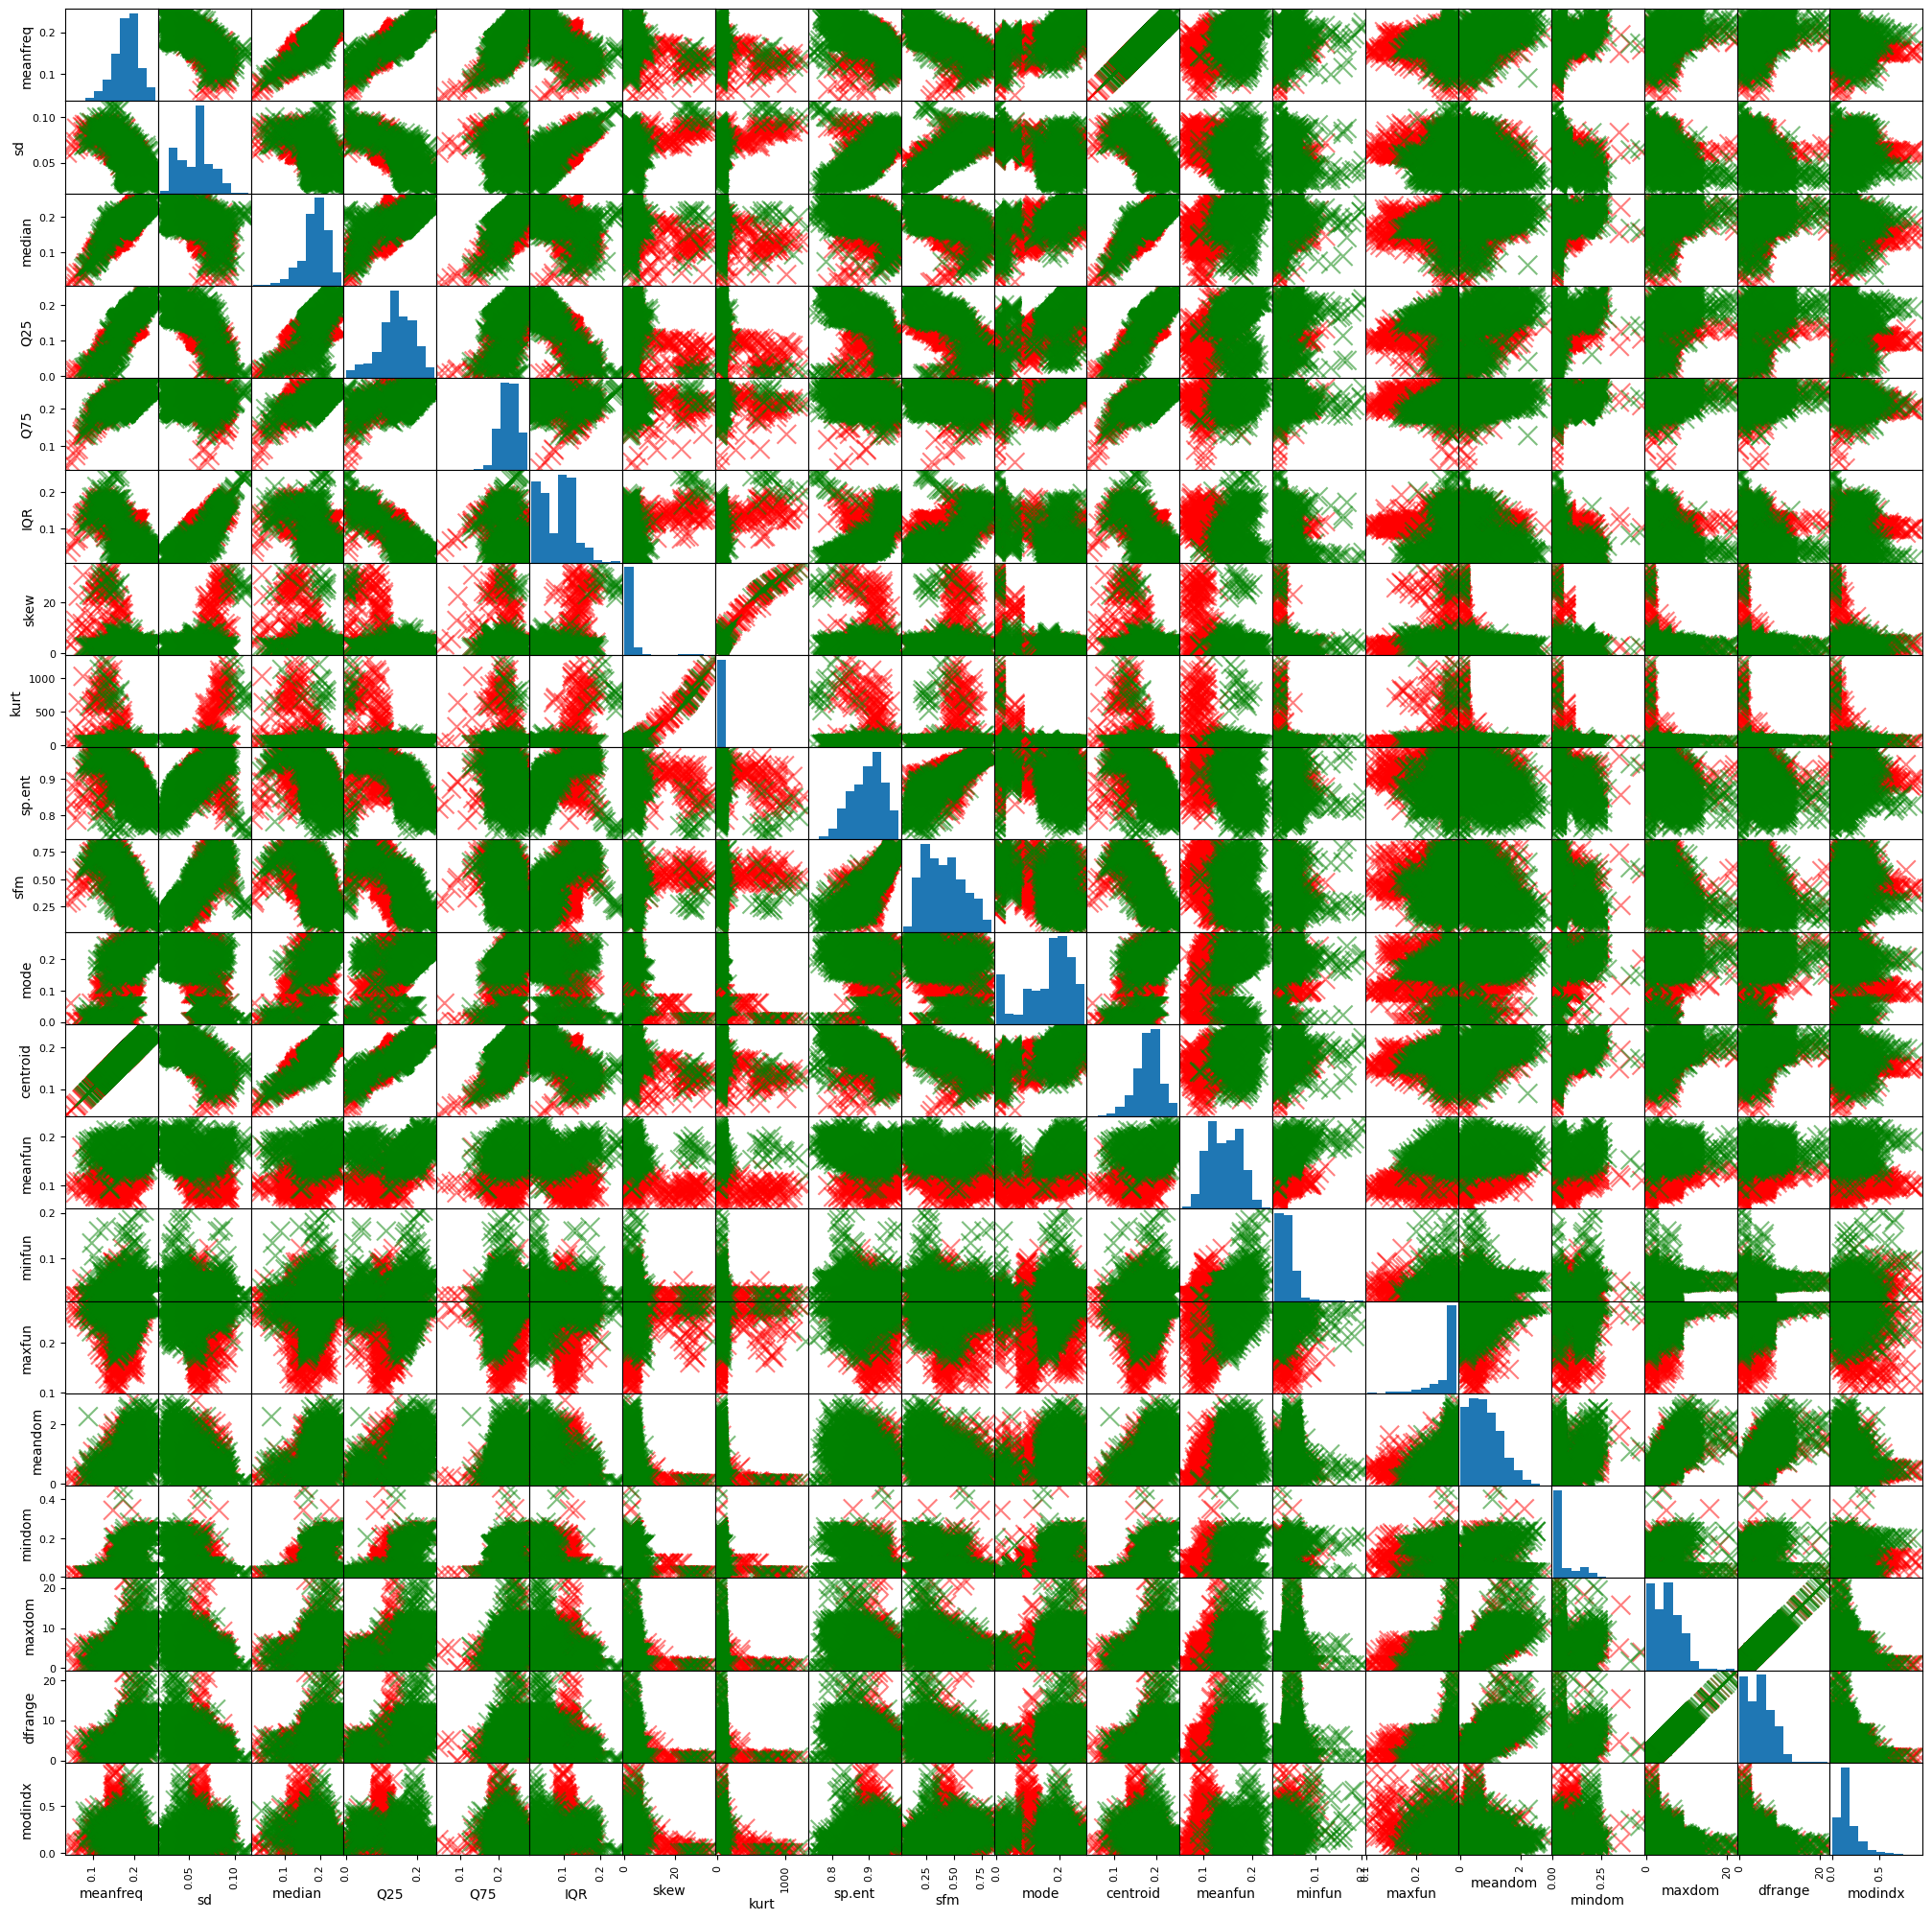

In [11]:
color_list = ['red' if i=='male' else 'green' for i in data.loc[:,'label']]
"""
Mỗi màu sẽ được chọn dựa trên giá trị của mỗi mục trong cột 'label' trong DataFrame 'data'. 
Nếu giá trị là 'male', màu sẽ là 'red', nếu không, màu sẽ là 'green'.
"""
pd.plotting.scatter_matrix(data.loc[:, data.columns != 'label'],
                          c=color_list,
                          figsize=[25,25],
                          diagonal='hist',
                          alpha=0.5,
                          s = 200,
                          marker = 'x',
                          edgecolor="black")
plt.show()

In [12]:
# Thay đổi giá trị trong cột label, 'male' thành 1 và 'female' thành 0
data.label = [1 if each == "male" else 0 for each in data.label]

#In ra thông tin của data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   int6

### 1.2 Tiền xử lý dữ liệu: Chuẩn bị và chuẩn hóa

In [ ]:
color_list = ['red' if i=='male' else 'green' for i in data.loc[:,'label']]
"""
Mỗi màu sẽ được chọn dựa trên giá trị của mỗi mục trong cột 'label' trong DataFrame 'data'. 
Nếu giá trị là 'male', màu sẽ là 'red', nếu không, màu sẽ là 'green'.
"""
pd.plotting.scatter_matrix(data.loc[:, data.columns != 'label'],
                          c=color_list,
                          figsize=[25,25],
                          diagonal='hist',
                          alpha=0.5,
                          s = 200,
                          marker = 'x',
                          edgecolor="black")
plt.show()

In [14]:
#Tạo một mảng y chỉ chưa các giá trị trong cột label
y = data.label.values

# Tạo ra một DataFrame mới x_data bằng cách loại bỏ cột "label" từ DataFrame "data"
x_data = data.drop(["label"],axis=1)

In [15]:
print(y)

[1 1 1 ... 0 0 0]


In [17]:
x_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
dtypes: float64(20)
memory usage: 4

#### 1.2.1 Chuẩn hóa dữ liệu

In [20]:
# x sẽ chứa dữ liệu đã được chuẩn hóa Min-Max, trong đó mỗi giá trị nằm trong khoảng từ 0 đến 1
x = (x_data - x_data.min(axis=0)) / (x_data.max(axis=0) - x_data.min(axis=0)).values

#### 1.2.2 Split tập Train và tập Test

In [21]:
from sklearn.model_selection import train_test_split

# Chia 20% cho tập test và 80% cho tập train
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state= 42)

In [22]:
# Chuyển vị các ma trận
x_train = x_train.T
x_test = x_test.T
y_train = y_train.T
y_test = y_test.T

In [23]:
# In ra kích thước các tập Train và Test
print("x_train: ",x_train.shape)
print("x_test: ",x_test.shape)
print("y_train: ",y_train.shape)
print("y_test: ",y_test.shape)

x_train:  (20, 2534)
x_test:  (20, 634)
y_train:  (2534,)
y_test:  (634,)


### 1.3 Huấn luyện Logistic Regression bằng function 

In [24]:
# lets initialize parameters
# So what we need is dimension, that is, the number of features as a parameter for our initialize method(def)
# dimension=2534
#initial weights=0.01, initial bias=0
#Hàm này sẽ trả về một cặp giá trị (w, b), trong đó w là ma trận trọng số với kích thước (dimension, 1) và b 
#là một số thực đại diện cho sai số ban đầu.
def initialize_weights_and_bias(dimension):
    
    #khởi tạo ma trận trọng số w có kích thước (dimension, 1) và tất cả các phần tử có giá trị là 0.01
    w = np.full((dimension,1),0.01)
    b = 0.0
    return w,b

#### Hàm sigmoid

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

$\sigma(x)$ :đầu ta từ 0 tới 1 (ước tính xác suất)   

x: Nhập vào hàm (thuật toán dự đoán của bạn)

In [25]:
# w,b = initialize_weights_and_bias(2534)
def sigmoid(z):
    
    y_head = 1/(1+ np.exp(-z))
    return y_head

#### Hàm Cross Entropy
$L\ =\ \frac{1}{N}\ \sum_{i=1}^N(y_i\log(p_i)+(1\ -y_i)\log(1-p_i))$

In [27]:
def forward_backward_propagation(w,b,x_train,y_train):
    # forward propagation
    z = np.dot(w.T,x_train) + b
    y_head = sigmoid(z)
    
    
    #Tính hàm mất mát entropy
    loss = -y_train*np.log(y_head)-(1-y_train)*np.log(1-y_head)
    
    # Hàm mất mát trung bình trên tất cả các mẫu trong tập huấn luyện.
    cost = (np.sum(loss))/x_train.shape[1]      # x_train.shape[1]  is for scaling
    
    # backward propagation
    """
    Tính toán đạo hàm theo trọng số. Sử dụng quy tắc lan truyền ngược, đạo hàm của hàm mất mát 
    theo trọng số được tính bằng phép nhân giữa dữ liệu huấn luyện x_train và hiệu giữa giá trị 
    dự đoán và nhãn thực tế (y_head - y_train).
    """
    derivative_weight = (np.dot(x_train,((y_head-y_train).T)))/x_train.shape[1] # x_train.shape[1]  is for scaling
    
    #Tính toán đạo hàm theo sai số là hiệu giữa giá trị dự đoán và nhãn thực tế, được tổng hợp trên tất cả các mẫu.
    derivative_bias = np.sum(y_head-y_train)/x_train.shape[1]                 # x_train.shape[1]  is for scaling
    
    
    gradients = {"derivative_weight": derivative_weight, "derivative_bias": derivative_bias}
    
    return cost,gradients

***Các bước Gradient Descent***

- Bước 1: Tính toán trung bình gradient với tất cả các điểm dữ liệu
- Bước 2: Nhân kết quả ở bước 1 với learing rate
- Bước 3: Thực hiện việc trừ weight(trừ nhưng chưa chắc giảm, vì trừ cho số âm thì thành cộng)

In [28]:
# Updating(learning) parameters
def update(w, b, x_train, y_train, learning_rate,number_of_iterarion):
    cost_list = []
    cost_list2 = []
    index = []
    
    # updating(learning) parameters is number_of_iterarion times
    for i in range(number_of_iterarion):
        # make forward and backward propagation and find cost and gradients
        cost,gradients = forward_backward_propagation(w,b,x_train,y_train)
        cost_list.append(cost)
        # lets update
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]
        if i % 10 == 0:
            cost_list2.append(cost)
            index.append(i)
            print ("Cost after iteration %i: %f" %(i, cost))
            
    # we update(learn) parameters weights and bias
    parameters = {"weight": w,"bias": b}
    plt.plot(index,cost_list2)
    plt.xticks(index,rotation='vertical')
    plt.xlabel("Number of Iterarion")
    plt.ylabel("Cost")
    plt.show()
    return parameters, gradients, cost_list

In [29]:
#prediction 
def predict(w,b,x_test):
    # x_test is a input for forward propagation
    z = sigmoid(np.dot(w.T,x_test)+b)
    Y_prediction = np.zeros((1,x_test.shape[1]))
    # if z is bigger than 0.5, our prediction is sign one (y_head=1),
    # if z is smaller than 0.5, our prediction is sign zero (y_head=0),
    for i in range(z.shape[1]):
        if z[0,i]<= 0.5:
            Y_prediction[0,i] = 0
        else:
            Y_prediction[0,i] = 1

    return Y_prediction

In [30]:
def logistic_regression(x_train, y_train, x_test, y_test, learning_rate ,  num_iterations):
    # initialize
    # num_iterations: Số lần lặp
    dimension =  x_train.shape[0]  # that is 30
    w,b = initialize_weights_and_bias(dimension)
    # do not change learning rate
    parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate,num_iterations)
    
    y_prediction_test = predict(parameters["weight"],parameters["bias"],x_test)

    # Print test Errors
    print("test accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))

#### 1.3.1: Tính toán và đánh giá hiệu suất

Cost after iteration 0: 0.695733
Cost after iteration 10: 0.570587
Cost after iteration 20: 0.511070
Cost after iteration 30: 0.472310
Cost after iteration 40: 0.442741
Cost after iteration 50: 0.418369
Cost after iteration 60: 0.397485
Cost after iteration 70: 0.379209
Cost after iteration 80: 0.363009
Cost after iteration 90: 0.348522


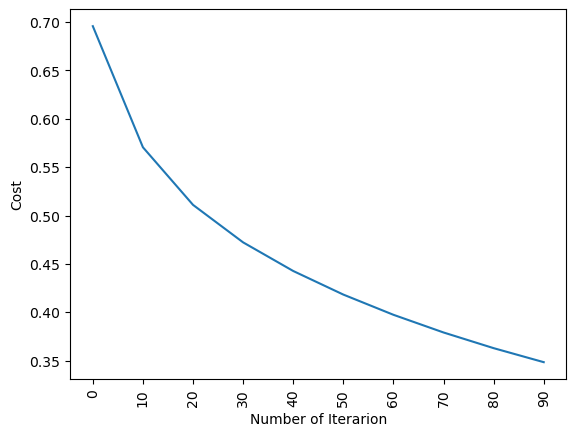

test accuracy: 92.74447949526814 %


In [31]:
# num_iterations = 100
logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 1, num_iterations = 100)

Cost after iteration 0: 0.695733
Cost after iteration 10: 0.570587
Cost after iteration 20: 0.511070
Cost after iteration 30: 0.472310
Cost after iteration 40: 0.442741
Cost after iteration 50: 0.418369
Cost after iteration 60: 0.397485
Cost after iteration 70: 0.379209
Cost after iteration 80: 0.363009
Cost after iteration 90: 0.348522
Cost after iteration 100: 0.335479
Cost after iteration 110: 0.323672
Cost after iteration 120: 0.312932
Cost after iteration 130: 0.303120
Cost after iteration 140: 0.294122
Cost after iteration 150: 0.285840
Cost after iteration 160: 0.278192
Cost after iteration 170: 0.271109
Cost after iteration 180: 0.264530
Cost after iteration 190: 0.258403


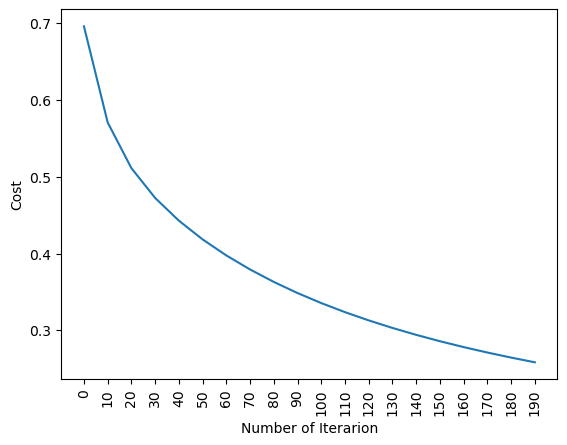

test accuracy: 95.89905362776025 %


In [32]:
# num_iterations = 200
logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 1, num_iterations = 200)

Cost after iteration 0: 0.695733
Cost after iteration 10: 0.570587
Cost after iteration 20: 0.511070
Cost after iteration 30: 0.472310
Cost after iteration 40: 0.442741
Cost after iteration 50: 0.418369
Cost after iteration 60: 0.397485
Cost after iteration 70: 0.379209
Cost after iteration 80: 0.363009
Cost after iteration 90: 0.348522
Cost after iteration 100: 0.335479
Cost after iteration 110: 0.323672
Cost after iteration 120: 0.312932
Cost after iteration 130: 0.303120
Cost after iteration 140: 0.294122
Cost after iteration 150: 0.285840
Cost after iteration 160: 0.278192
Cost after iteration 170: 0.271109
Cost after iteration 180: 0.264530
Cost after iteration 190: 0.258403
Cost after iteration 200: 0.252683
Cost after iteration 210: 0.247332
Cost after iteration 220: 0.242314
Cost after iteration 230: 0.237600
Cost after iteration 240: 0.233163
Cost after iteration 250: 0.228979
Cost after iteration 260: 0.225027
Cost after iteration 270: 0.221289
Cost after iteration 280: 0.217

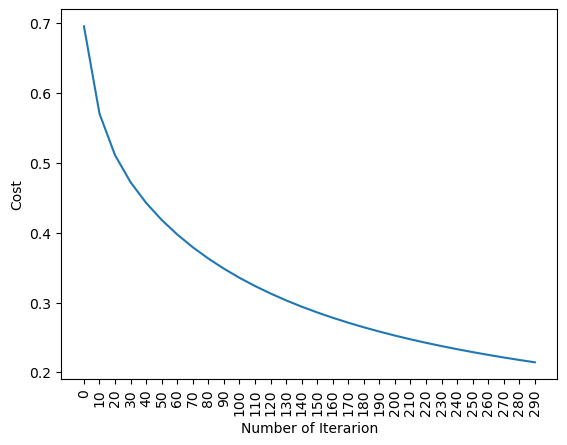

test accuracy: 97.1608832807571 %


In [33]:
# num_iterations = 300
logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 1, num_iterations = 300)

### 1.4 Huấn luyện theo Logistic Regression của Sci-kitlearn

In [36]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

lr.fit(x_train.T,y_train.T)
print("test accuracy {}".format(lr.score(x_test.T,y_test.T)))

test accuracy 0.9826498422712934


In [37]:
from sklearn.metrics import precision_score, recall_score

# Dự đoán nhãn dựa trên dữ liệu kiểm tra
y_pred = lr.predict(x_test.T)

# Tính precision và recall
precision = precision_score(y_test.T, y_pred)
recall = recall_score(y_test.T, y_pred)

# In ra precision và recall
print("Precision:", precision)
print("Recall:", recall)


Precision: 0.9822485207100592
Recall: 0.9851632047477745


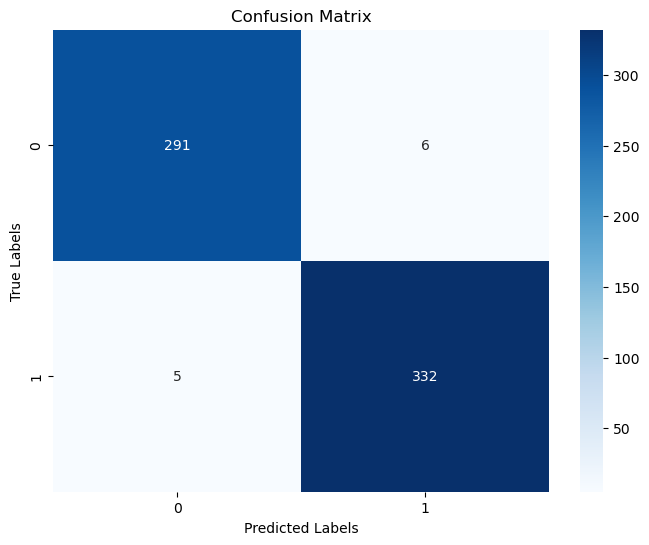

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Dự đoán nhãn dựa trên dữ liệu kiểm tra
y_pred = lr.predict(x_test.T)

# Tính confusion matrix
cm = confusion_matrix(y_test.T, y_pred)

# Vẽ biểu đồ confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


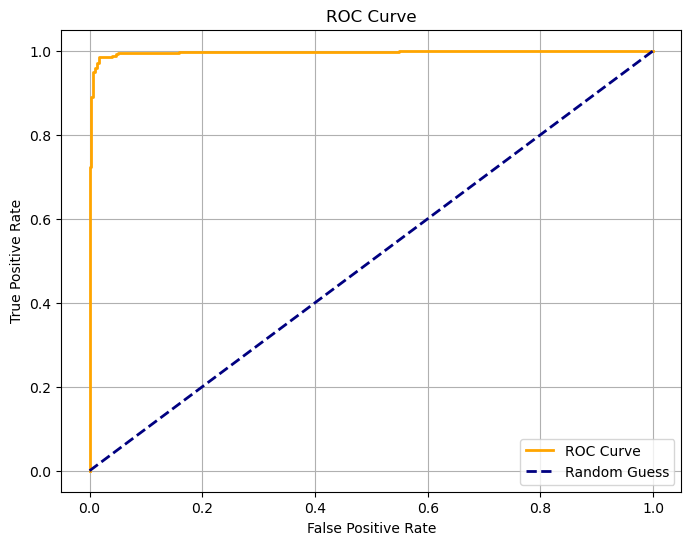

AUC: 0.9960335301581593


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

# Dự đoán xác suất dương cho nhãn 1 (sử dụng predict_proba)
y_probs = lr.predict_proba(x_test.T)[:, 1]

# Tính ROC curve
fpr, tpr, thresholds = roc_curve(y_test.T, y_probs)

# Vẽ ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# Tính AUC
auc = roc_auc_score(y_test.T, y_probs)
print("AUC:", auc)


In [40]:
from sklearn.model_selection import cross_val_score

# Sử dụng cross-validation với 5 folds
scores = cross_val_score(lr, x_train.T, y_train.T, cv=5)

# In ra kết quả của cross-validation
print("Cross-Validation Scores:", scores)

# In ra độ chính xác trung bình và độ lệch chuẩn của cross-validation scores
print("Mean Accuracy:", scores.mean())
print("Standard Deviation of Accuracy:", scores.std())


Cross-Validation Scores: [0.95463511 0.97238659 0.96449704 0.96449704 0.9743083 ]
Mean Accuracy: 0.9660648158975919
Standard Deviation of Accuracy: 0.006978164250468173
